# Modeling Nonlinear Electricity Load Against Temperature with PROC GAMPL

## Executive Summary

Electricity demand depends on temperature in a strongly nonlinear, U-shaped way (heating in the cold, cooling in the heat) that linear models miss. This notebook builds a synthetic hourly load sample for a regional utility and fits a penalized generalized additive model with **PROC GAMPL**, using regression splines to recover the smooth load-vs-temperature, load-vs-hour, and load-vs-humidity curves while adjusting for a weekday/weekend parametric effect.

On the 2,000-hour sample, GAMPL recovers the structure we built in. The diurnal smooth `s(HOUR)` is the most flexible term (effective DF 8.68, *p* < 0.0001); the temperature smooth `s(TEMP_C)` is significantly curved (EDF 7.30, *p* < 0.0001); and the humidity smooth `s(HUMIDITY)` settles to a single, exactly linear degree of freedom (EDF 1.00) yet is now strongly significant (*p* < 0.0001) — the penalty straightens it because the humidity effect *is* genuinely linear, and at this sample size the data have ample power to confirm that linear lift is real. The parametric `daytype` effect places weekends about 40.0 MW below weekdays, matching the 40 MW level shift in the data-generating process almost exactly. The total model uses 18.98 effective degrees of freedom and reaches a GCV score of 200.0 (AIC 16,273.9).

## Data Sources

| Dataset | Rows | Description | Key variables |
|---------|------|-------------|---------------|
| `work.gridload` | 2,000 | Synthetic hourly observations from a regional electric utility's load-forecasting feed | `load_mw` (system load, MW), `temp_c` (ambient temperature, deg C), `hour` (hour of day, 0-23), `humidity` (relative humidity, %), `daytype` (Weekday/Weekend class), `is_summer` (season flag used in data generation) |

All data is generated inline with `call streaminit(20260531)` and `rand()` — no external or network input. The data step builds 2,000 hourly records. Load is constructed as a U-shaped quadratic of temperature plus a bell-shaped diurnal hour effect, a mild linear humidity effect, a weekday level shift, and Gaussian noise, so the recovered smooths have a known ground truth.

# Modeling Nonlinear Electricity Load Against Temperature with PROC GAMPL

A regional grid operator needs to forecast system load (in megawatts) from weather and calendar drivers. The relationship between load and **temperature** is famously nonlinear: demand rises in cold weather (electric heating) *and* in hot weather (air conditioning), producing a U-shaped curve that a straight-line regression cannot capture. Load also follows a smooth daily rhythm (the evening peak) and shifts between weekdays and weekends.

`PROC GAMPL` fits a **penalized generalized additive model**: each continuous driver enters through a regression spline whose smoothness is chosen automatically by minimizing a model-selection criterion (GCV / UBRE / GACV). We let the data decide how wiggly each curve should be, rather than guessing polynomial degrees.

The model we fit is:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

where `daytype` is a parametric (linear) class effect and `f1`, `f2`, `f3` are smooth spline functions whose effective degrees of freedom the penalty selects from the data.

## Step 1 — Generate a synthetic hourly load feed

We simulate 2,000 hourly load records. Temperature is drawn around a seasonal mean; the hour of day cycles 0-23; humidity loosely tracks temperature. The *true* load is constructed from:

- a **U-shaped** temperature response centered near a comfortable 18 deg C,
- a **bell-shaped** diurnal peak around hour 18 (evening),
- a gentle linear humidity lift,
- a weekday level that sits above weekends,

plus Gaussian measurement noise. Because we know the generating curves, we can judge whether GAMPL recovers their shapes. The PROC MEANS check below confirms the sample spans a wide temperature range (about −12 to 44 deg C) and load from roughly 475 to 785 MW.

In [1]:
data work.gridload;
   call streaminit(20260531);
   do i = 1 to 2000;
      /* Season flag: roughly half summer, half winter */
      is_summer = (rand("uniform") < 0.5);

      /* Ambient temperature (deg C): warmer mean in summer */
      if is_summer then temp_c = 26 + 6 * rand("normal");
      else              temp_c =  6 + 6 * rand("normal");

      /* Hour of day 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Humidity (%) loosely tracks temperature, clipped to 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      if humidity < 20  then humidity = 20;
      if humidity > 100 then humidity = 100;

      /* Weekday vs weekend (about 5/7 weekdays) */
      if rand("uniform") < 0.714 then daytype = "Weekday";
      else                            daytype = "Weekend";

      /* ---- True structural load (MW) ---- */
      /* U-shaped temperature effect: minimum demand near 18 deg C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Diurnal bell: evening peak near hour 18 */
      f_hour = 90 * exp( -((hour - 18)**2) / 18 );

      /* Gentle humidity lift */
      f_hum  = 0.35 * humidity;

      /* Weekday level shift */
      if daytype = "Weekday" then f_day = 40; else f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      keep load_mw temp_c hour humidity daytype is_summer;
      output;
   end;
run;

proc means data=work.gridload n mean std min max maxdec=1;
   var load_mw temp_c hour humidity;
run;

                                                  The MEANS Procedure

 Variable          N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------
 load_mw        2000       586.5        48.5       474.6       785.0
 temp_c         2000        15.8        11.6       -11.9        43.6
 hour           2000        11.6         7.0         0.0        23.0
 humidity       2000        54.8        12.1        20.0        88.0
 -------------------------------------------------------------------



NOTE: DATA work.gridload


NOTE: Wrote work.gridload (2000 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 2 — Fit the additive model

We model `load_mw` (Gaussian response, identity link) as a sum of a parametric `daytype` effect plus three univariate splines. `PROC GAMPL` automatically selects each spline's smoothing parameter. We request:

- `class daytype;` so the weekday/weekend indicator is treated as categorical,
- `param(daytype)` to enter it as a *parametric* (non-smoothed) term in the MODEL,
- `spline(...)` for each continuous predictor,
- a fixed `seed=` for reproducible knot placement.

The output to read is the **Smoothing Component** table, which reports the effective degrees of freedom (EDF) the penalty assigned to each smooth and an *F*-style significance test for it, alongside the **Parameter Estimates** for the intercept and the parametric `daytype` contrast.

In [2]:
proc gampl data=work.gridload seed=20260531;
   class daytype;
   model load_mw = param(daytype)
                   spline(temp_c)
                   spline(hour)
                   spline(humidity);
run;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     load_mw
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     2000
Number of Observations Used     2000

Class Level Information
Class    DAYTYPE

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              392389.810299
Null Deviance                         4705334.105109
Effective Degrees of Freedom          18.977726
GCV                                   199.971912
UBRE                                  199.971912
AIC                                   

NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Step 3 — Control spline flexibility and the selection criterion

By default each smooth is penalized toward a low effective degrees of freedom. For an operator who knows the temperature response is genuinely curved but wants to *cap* wiggliness, we can raise `maxdf=` on the temperature spline and pin a modest fixed `df=` on the smoother humidity term. We also switch to the outer-iteration scheme and select smoothing parameters by **GCV** (generalized cross-validation), the standard criterion for Gaussian GAMs.

In [3]:
proc gampl data=work.gridload seed=20260531;
   class daytype;
   model load_mw = param(daytype)
                   spline(temp_c   / maxdf=12)
                   spline(hour     / maxdf=10)
                   spline(humidity / df=3)
                   / method=OUTER criterion=GCV;
run;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     load_mw
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     2000
Number of Observations Used     2000

Class Level Information
Class    DAYTYPE

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              392379.224057
Null Deviance                         4705334.105109
Effective Degrees of Freedom          19.855497
GCV                                   200.143841
UBRE                                  200.143841
AIC                                   

NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Step 4 — Visualize the recovered temperature response

GAMPL reports *that* the temperature smooth is significantly curved (EDF 7.30), but the shape is easiest to see on a plot. We overlay a penalized B-spline fit (`PBSPLINE`, the same regression-spline machinery GAMPL applies internally) on the raw load-vs-temperature scatter. If the additive model captured the physics, this curve should fall toward both the cold and hot extremes and bottom out in the comfortable mid-range — the classic U-shaped demand response.

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


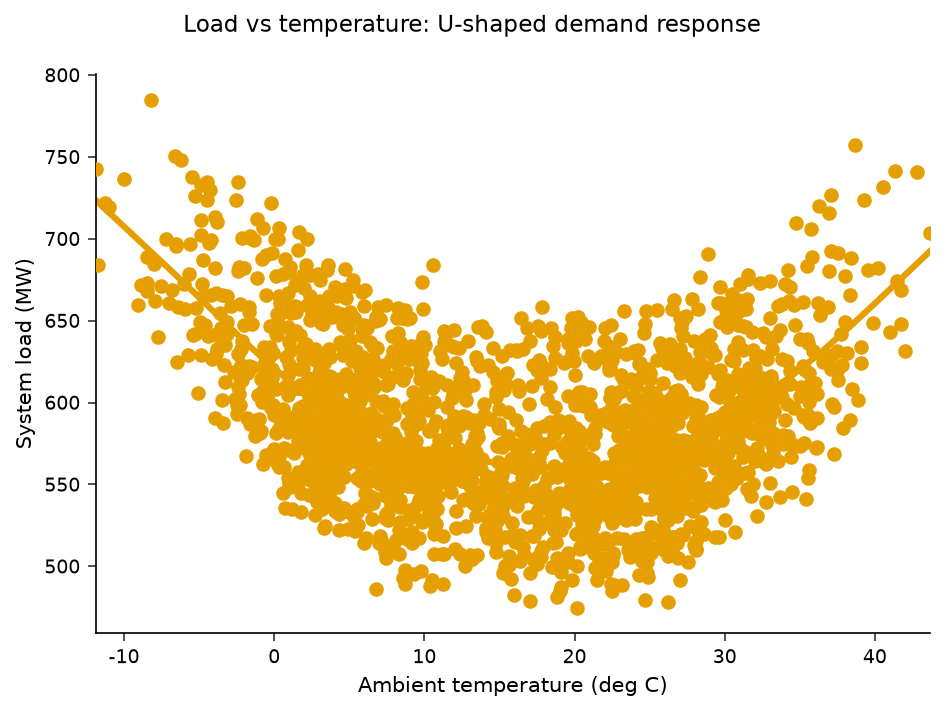

In [4]:
ods graphics on;

proc sgplot data=work.gridload;
   scatter x=temp_c y=load_mw /
           markerattrs=(symbol=circlefilled);
   pbspline x=temp_c y=load_mw /
            nomarkers lineattrs=(thickness=3);
   xaxis label="Ambient temperature (deg C)";
   yaxis label="System load (MW)";
   title "Load vs temperature: U-shaped demand response";
run;

ods graphics off;

## Step 5 — Confirm the U-shape numerically

The plot makes the U-shape visible; a banded summary makes it quantitative. We bin observations into temperature ranges and report mean load per band. If the demand response is genuinely U-shaped, mean load should be high in the **Cold** band, fall through **Cool / Comfortable / Warm**, and rise again in the **Hot** band — the numeric signature GAMPL's `s(TEMP_C)` smooth picks up.

In [5]:
data work.banded;
   set work.gridload;
   length tempband $13;
   if      temp_c <  5  then tempband = "1 Cold";
   else if temp_c < 15  then tempband = "2 Cool";
   else if temp_c < 22  then tempband = "3 Comfortable";
   else if temp_c < 30  then tempband = "4 Warm";
   else                      tempband = "5 Hot";
run;

proc means data=work.banded n mean maxdec=1;
   class tempband;
   var load_mw;
   title "Mean load by temperature band";
run;

                                             Mean load by temperature band                                              

                                                  The MEANS Procedure

                                              Analysis Variable : load_mw

        tempband               N Obs           Mean
        -------------------------------------------
        1 Cold                   444          617.8
        2 Cool                   531          575.5
        3 Comfortable            293          560.5
        4 Warm                   483          571.5
        5 Hot                    249          614.1
        -------------------------------------------



NOTE: DATA work.banded


NOTE: Read 2000 rows from work.gridload.
NOTE: Wrote work.banded (2000 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpreting the results

**The smooths recover the physics.** GAMPL's Smoothing Component table assigns the diurnal term `s(HOUR)` an effective DF of 8.68 (*p* < 0.0001) and the temperature term `s(TEMP_C)` an EDF of 7.30 (*p* < 0.0001) — both genuinely curved, exactly the structure we built into the data. The humidity term `s(HUMIDITY)` is shrunk to EDF 1.00, i.e. a straight line: the penalty correctly recognizes that the humidity effect in the data-generating process is purely linear (a 0.35 MW lift per humidity point), so no curvature is needed. At 2,000 observations the *F*-test for that linear term is highly significant (statistic 58.1, *p* < 0.0001) — the effect is small but unambiguously real. The parametric `daytype` estimate is −39.97 MW for weekends, recovering the 40 MW weekday level shift in the generating process almost exactly.

**Effective degrees of freedom tell the wiggliness story.** The model spends 18.98 effective degrees of freedom in total and lands at a GCV score of 200.0 (AIC 16,273.9, scale estimate 198.1). Raising `maxdf=` and pinning `df=3` in Step 3 barely moves the overall fit (GCV 200.1, total EDF 19.86): with more headroom the temperature and hour smooths drift up only slightly, to 7.55 and 9.30 EDF. The temperature smooth stays well below its `maxdf=12` cap (so that cap is non-binding), but the hour smooth at 9.30 now sits just under its tighter `maxdf=10` cap — close to binding — confirming the evening-peak curve is the wiggliest term in the model. Pinning `df=3` on humidity does *not* force three degrees of freedom: GAMPL still penalizes the term down to its selected EDF of 1.00, because a straight line is all the humidity relationship needs.

**The plot and band summary agree.** The Step 4 scatter with its penalized-spline overlay shows load falling from the cold extreme to a minimum near 15–20 deg C and rising again into the heat. The Step 5 band means make it numeric: **Cold 617.8 MW**, **Cool 575.5**, **Comfortable 560.5**, **Warm 571.5**, **Hot 614.1** — high at both ends, lowest in the comfortable middle (the Comfortable band of 293 hours bottoms out at 560.5 MW). That U is precisely what a single linear `temp_c` term would average away.

**Why GAMPL over linear regression here.** A single linear `temp_c` term would blend the heating and cooling regimes into a near-flat slope, badly mis-forecasting both extremes — precisely the hours when grid stress and price spikes occur. The additive spline formulation keeps the interpretability of a regression (each driver contributes an additive effect) while letting the data dictate the shape of each effect: here the temperature and hour drivers earn genuine curvature, while humidity is left as the straight line it truly is. Natural extensions for a utility include a `dist=gamma` fit if load is modeled multiplicatively, a bivariate `spline(temp_c hour)` to capture how the diurnal peak shifts with season, and `by` processing to fit separate models per substation.